## CUSTOMER SEGEMENTATION WITH K MEANS

In [0]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from delta.tables import DeltaTable

In [0]:
df = spark.sql("""
SELECT *
FROM resume_project.gold_layer.customer_features
""")
display(df)

customer_id,last_order_date,days_since_last_purchase,num_orders,total_revenue,avg_revenue,total_quantity_purchased,unique_products_purchased,unique_categories_purchased
38,2025-06-28,290,11,6052.09,550.19,25,11,5
93,2025-06-28,290,11,4887.82,444.35,25,10,4
161,2025-06-28,290,14,6232.67,445.19,34,13,5
190,2025-06-28,290,15,7202.3,480.15,39,14,5
12,2025-06-28,290,14,4662.48,333.03,29,14,5
186,2025-06-28,290,10,6405.15,640.52,26,9,4
67,2025-06-28,290,7,2477.03,353.86,16,7,5
70,2025-06-28,290,11,5338.2,485.29,29,11,5
18,2025-06-28,290,6,3312.89,552.15,13,6,4
105,2025-06-28,290,8,4757.27,594.66,19,8,4


In [0]:
##converting to pandas df
rfm_df = df.select(
    "customer_id",
    "days_since_last_purchase",
    "num_orders",
    "total_revenue"
).toPandas()
display(rfm_df)

customer_id,days_since_last_purchase,num_orders,total_revenue
38,290,11,6052.09
93,290,11,4887.82
161,290,14,6232.67
190,290,15,7202.3
12,290,14,4662.48
186,290,10,6405.15
67,290,7,2477.03
70,290,11,5338.2
18,290,6,3312.89
105,290,8,4757.27


In [0]:
rfm_df.columns = ['Customer_ID','Recency', 'Frequency', 'Monetary']
display(rfm_df)


Customer_ID,Recency,Frequency,Monetary
38,290,11,6052.09
93,290,11,4887.82
161,290,14,6232.67
190,290,15,7202.3
12,290,14,4662.48
186,290,10,6405.15
67,290,7,2477.03
70,290,11,5338.2
18,290,6,3312.89
105,290,8,4757.27


### Monetary Distribution

In [0]:
##checking distribution of monetary column
rfm_df['Monetary'].describe()


count      200.000000
mean      5054.477850
std       2106.730204
min        870.540000
25%       3556.460000
50%       4859.420000
75%       6409.695000
max      11934.030000
Name: Monetary, dtype: float64

In [0]:
rfm_df['Monetary'].skew()

np.float64(0.4399205778739604)

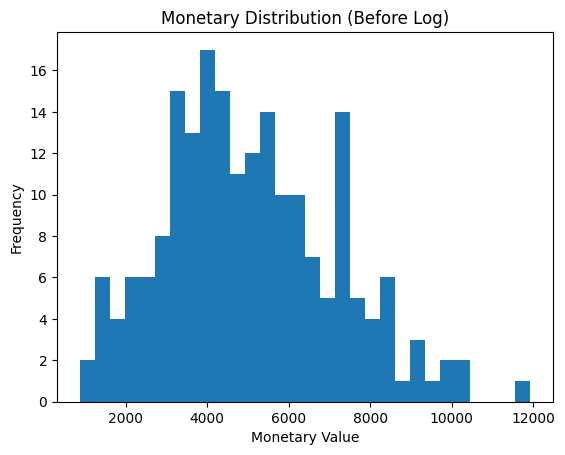

In [0]:
plt.hist(rfm_df['Monetary'], bins=30)
plt.title('Monetary Distribution (Before Log)')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')
plt.show()

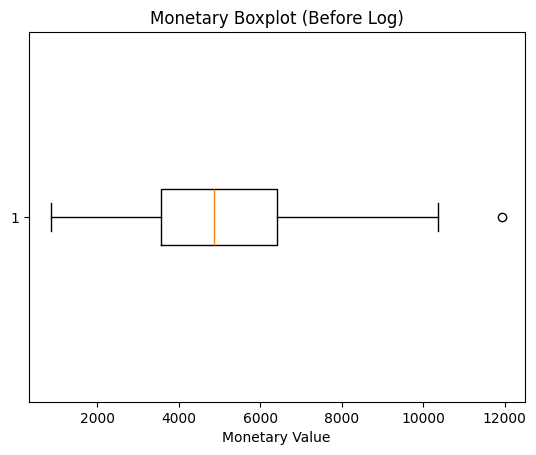

In [0]:
plt.boxplot(rfm_df['Monetary'], vert=False)
plt.title('Monetary Boxplot (Before Log)')
plt.xlabel('Monetary Value')
plt.show()

Distribution of monetary is right-skewed due to heavy spender outliers. Will log-transform so each type of customer is properly grouped.

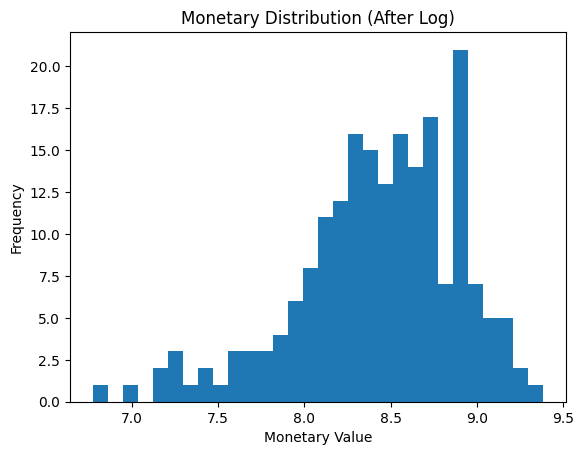

In [0]:
##log transform of monetary column
rfm_df['Monetary'] = np.log1p(rfm_df['Monetary'])
plt.hist(rfm_df['Monetary'], bins=30)
plt.title('Monetary Distribution (After Log)')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')
plt.show()

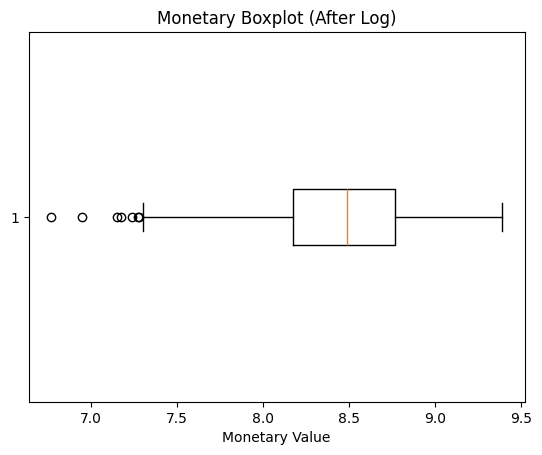

In [0]:
plt.boxplot(rfm_df['Monetary'], vert=False)
plt.title('Monetary Boxplot (After Log)')
plt.xlabel('Monetary Value')
plt.show()

In [0]:
rfm_df['Monetary'].describe()

count    200.000000
mean       8.429213
std        0.473237
min        6.770262
25%        8.176795
50%        8.488874
75%        8.765722
max        9.387233
Name: Monetary, dtype: float64

In [0]:
rfm_df['Monetary'].skew()

np.float64(-0.8018546262486353)

Mean is approximately equal to the median. Max and min are not as far apart from the mean/median. 

### Standardization
Normalizing the columns so they are on the same scale for K-means

In [0]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

## Finding optimal value for K for K means

In [0]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

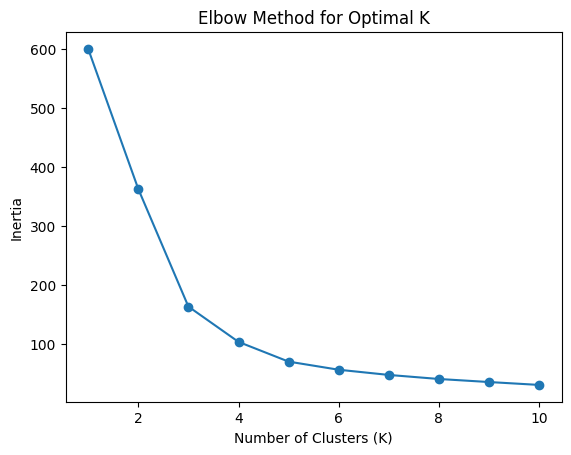

In [0]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

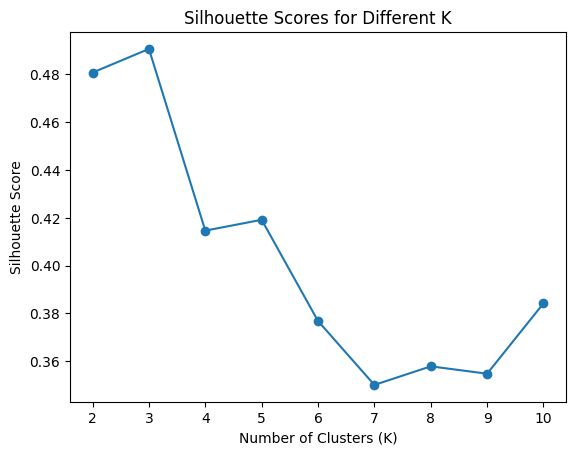

In [0]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)

plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K')
plt.show()

The elbow and silhouette methods point towards k=6 as being the optimal k. This is because 6 has a low  silhouette score and there is diminishing returns after k=6 for the elbow method.

## Fitting Final model with optimal K

In [0]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [0]:
display(rfm_df)

Customer_ID,Recency,Frequency,Monetary,Cluster,Segment
38,290,11,8.708324164441319,3,High Value
93,290,11,8.49470624455581,0,High Value
161,290,14,8.73772052341123,3,High Value
190,290,15,8.882294533334841,4,High Value
12,290,14,8.447517229533299,3,High Value
186,290,10,8.765013745442888,0,High Value
67,290,7,7.815219168653335,5,Mid Value
70,290,11,8.582831107997109,0,High Value
18,290,6,8.105878004919028,5,Mid Value
105,290,8,8.467639435785037,0,Mid Value


In [0]:
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          290.0  10.032787  8.504737
1          290.0   5.312500  7.360080
2          362.0   6.000000  7.747873
3          290.0  12.422222  8.816793
4          290.0  15.954545  8.991239
5          290.0   7.036364  8.126939


In [0]:
rfm_df['Cluster'].value_counts().sort_index()

Cluster
0    61
1    16
2     1
3    45
4    22
5    55
Name: count, dtype: int64

In [0]:
rfm_df['Segment'] = rfm_df['Cluster'].map({
    4: 'High Value',
    3: 'High Value',
    0: 'Mid Value',
    5: 'Mid Value',
    1: 'Low Value',
    2: 'At Risk'
})
rfm_df['Segment'].value_counts(normalize=True)

Segment
Mid Value     0.580
High Value    0.335
Low Value     0.080
At Risk       0.005
Name: proportion, dtype: float64

In [0]:
display(rfm_df)

Customer_ID,Recency,Frequency,Monetary,Cluster,Segment
38,290,11,8.708324164441319,3,High Value
93,290,11,8.49470624455581,0,Mid Value
161,290,14,8.73772052341123,3,High Value
190,290,15,8.882294533334841,4,High Value
12,290,14,8.447517229533299,3,High Value
186,290,10,8.765013745442888,0,Mid Value
67,290,7,7.815219168653335,5,Mid Value
70,290,11,8.582831107997109,0,Mid Value
18,290,6,8.105878004919028,5,Mid Value
105,290,8,8.467639435785037,0,Mid Value


In [0]:
##converting to spark df to write the table to gold layer
spark_rfm_df = spark.createDataFrame(rfm_df)

In [0]:
target_table = "resume_project.gold_layer.customer_segments"

if spark.catalog.tableExists(target_table):
    delta_tbl = DeltaTable.forName(spark, target_table)

    (
        delta_tbl.alias("trg")
        .merge(
            spark_rfm_df.alias("src"),
            "trg.customer_id = src.customer_id"
        )
        .whenMatchedUpdateAll()
        .whenNotMatchedInsertAll()
        .execute()
    )
else:
    (
        spark_rfm_df.write
        .format("delta")
        .mode("overwrite")
        .saveAsTable(target_table)
    )

## Conclusions
Based on the identified customer segments, targeted strategies were proposed to improve engagement and revenue. High-value customers can be retained through loyalty programs and exclusive offers, mid-value customers can be encouraged to increase spend through upselling and cross-selling initiatives, and at-risk customers can be re-engaged by personalized marketing campaigns and promotions aimed at reducing churn.